# Regresion Basica: Predecir eficiencia de gasolina

Este libro usa el set de datos clasico [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) y construye un modelo para predecir el consumo de vehiculos de 1970 y 1980. Para hacer esto proveeremos el modelo con una descripcion de muchos automoviles de ese periodo. Esta descripcion incluye atributos como: Cilindros, desplazamiento, potencia y peso.

El objetivo de este ejercicio es predecir el target miles per galon (MPG), que vendría a representar las millas por galón de combustible.

Este ejemplo usa el API `tf.keras` , revise [Esta Guia](https://www.tensorflow.org/guide/keras) para obtener mas detalles.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

## El set de Datos de MPG

El set de datos esta disponible de el siguiente repositorio [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/).

### Obtenga los datos
Primero descargue el set de datos.
keras.utils.get_file("auto-mpg.data", "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")

In [2]:
data = keras.utils.get_file('auto-mpg.data', 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data')

Importelo usando pandas.

In [3]:
column_names = ["MPG", "Cylinders", "Displacement", "Horsepower", "Weight", "Acceleration", "Model Year", "Origin", "Car name"]

In [4]:
vehiculos = pd.read_csv(data, names=column_names,
                 na_values='?', comment='\t',
                 sep=' ', skipinitialspace=True)
vehiculos.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,NaN
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,NaN
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,NaN
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,NaN
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,NaN


### Limpia los datos

Trata los missings y variables categóricas

In [5]:
vehiculos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
 8   Car name      0 non-null      float64
dtypes: float64(6), int64(3)
memory usage: 28.1 KB


In [6]:
# Eliminar 'Car name', no contiene nada
vehiculos = vehiculos.drop(columns=['Car name'])

# Arreglar missings
vehiculos['Horsepower'] = vehiculos['Horsepower'].fillna(vehiculos['Horsepower'].median())

# Encoding de 'Origin'
vehiculos['Origin'] = vehiculos['Origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})
vehiculos = pd.get_dummies(vehiculos, columns=['Origin'], prefix='', prefix_sep='')

vehiculos .head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,False,False,True
1,15.0,8,350.0,165.0,3693.0,11.5,70,False,False,True
2,18.0,8,318.0,150.0,3436.0,11.0,70,False,False,True
3,16.0,8,304.0,150.0,3433.0,12.0,70,False,False,True
4,17.0,8,302.0,140.0,3449.0,10.5,70,False,False,True


### Divide los datos en train y test

Ahora divida el set de datos en un set de entrenamiento y otro de pruebas. 80% para entrenamiento

Usaremos el set de pruebas en la evaluacion final de nuestro modelo.

NOTA: El resultado tienen que ser dos datasets

In [7]:
train_df = vehiculos.sample(frac=0.8, random_state=42)
test_df = vehiculos.drop(train_df.index)

print(train_df.shape, test_df.shape)

(318, 10) (80, 10)


### Inspecciona los datos

Revise rapidamente la distribucion conjunta del dataset de entrenamiento mediante un grid de gráficos

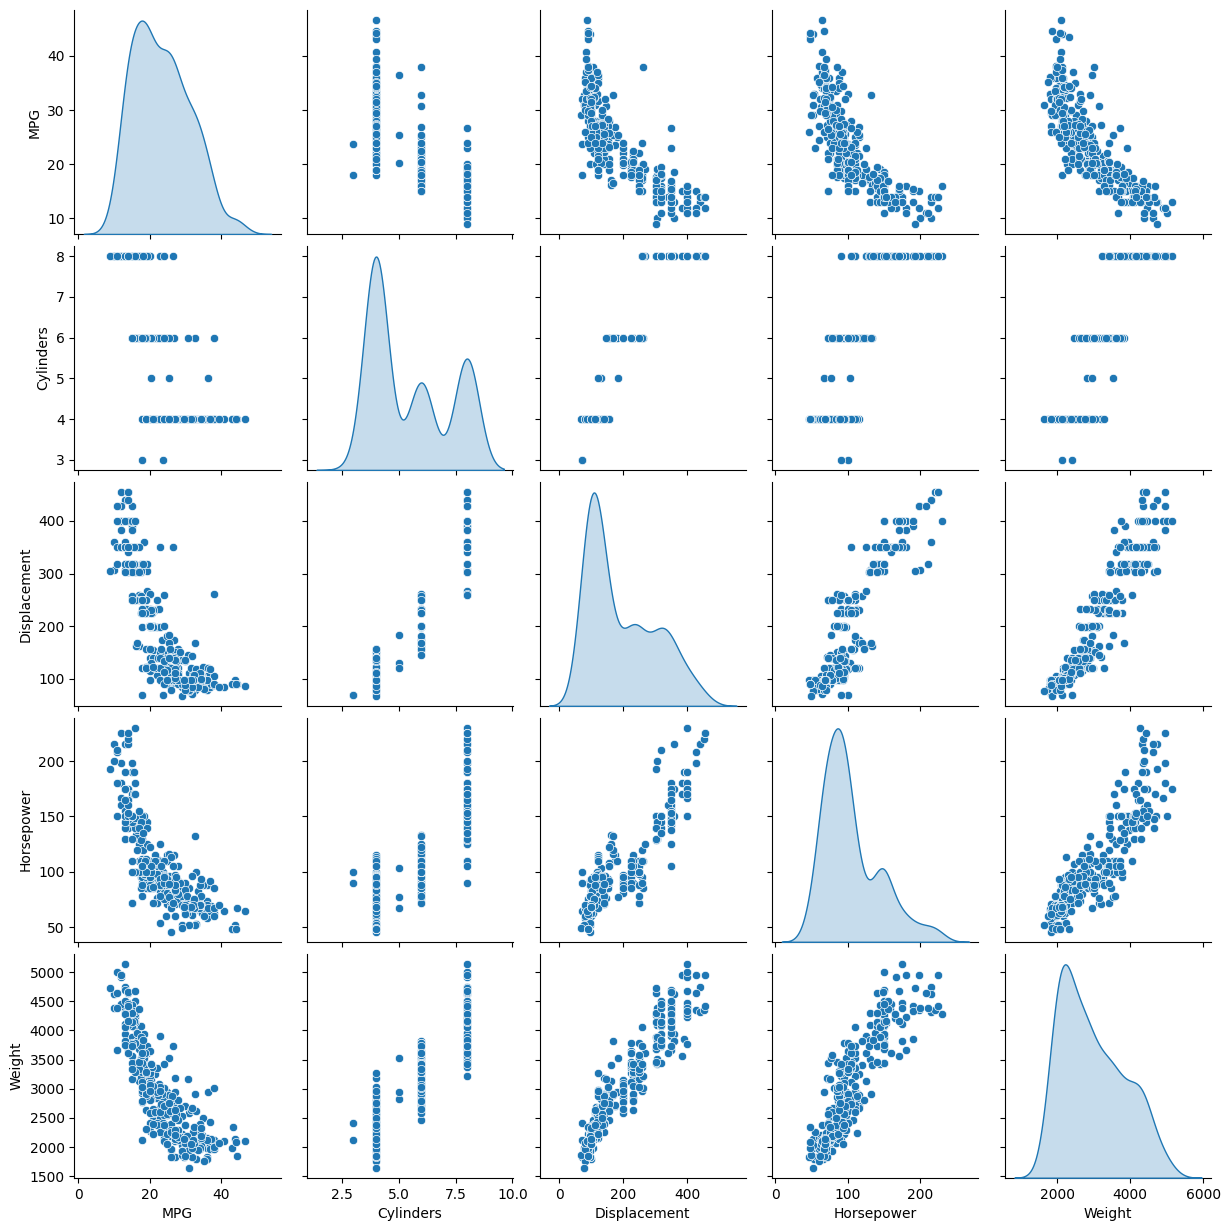

In [8]:
sns.pairplot(train_df[['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight']], diag_kind='kde');

Tambien revise las estadisticas generales:

In [9]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
MPG,318.0,23.456289,7.852373,9.0,17.125,23.0,29.000,46.6
Cylinders,318.0,5.487421,1.708625,3.0,4.000,4.0,8.000,8.0
Displacement,318.0,195.088050,105.719490,68.0,100.250,148.0,293.250,455.0
Horsepower,318.0,104.520440,39.290599,46.0,75.000,93.5,128.000,230.0
Weight,318.0,2983.591195,860.538663,1649.0,2220.750,2818.5,3627.500,5140.0
Acceleration,318.0,15.632704,2.801216,8.0,14.000,15.5,17.275,24.8
Model Year,318.0,75.946541,3.711221,70.0,73.000,76.0,79.000,82.0


### Separa las features del target

Separe el target de las features.

In [10]:
X_train = train_df.drop(columns=['MPG'])
y_train = train_df['MPG']

X_test = test_df.drop(columns=['MPG'])
y_test = test_df['MPG']

### Estandariza los datos

Es una buena práctica estandarizar funciones que utilizan diferentes escalas y rangos. Aunque el modelo podría converger sin estandarizar, dificulta el entrenamiento y hace que el modelo resultante dependa de la elección de las unidades utilizadas en la entrada.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Ajustamos SOLO con train y transformamos ambos
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

Estos datos estandarizados es lo que usaremos para entrenar el modelo.

## El modelo

### Construye el modelo

Construyamos nuestro modelo. Aquí, utilizaremos un modelo `secuencial` con dos capas ocultas densamente conectadas y una capa de salida que devuelve un único valor continuo.

Por tanto, tendrá tres capas. Una de entrada con activación relu. Otra hidden layer con activación relu y la de salida de regresión, que se compondrá de una única neurona. Pon las neuronas que consideres para las dos primeras capas.

Para el compile utiliza un loss='mse'.

optimizer = `tf.keras.optimizers.RMSprop(0.001)`

Y en metrics añade en una lista el `mae` y `mse`.

In [12]:
import tensorflow as tf

model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=[X_train_std.shape[1]]),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)  # Salida: MPG
])


model.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.RMSprop(0.001),
    metrics=['mae', 'mse']
)

### Inspeccione el modelo

Use el método `.summary` para imprimir una descripción simple del modelo

In [13]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                640       
                                                                 
 dense_1 (Dense)             (None, 64)                4160      
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 4865 (19.00 KB)
Trainable params: 4865 (19.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Entrenar el modelo

Entrene el modelo para 1000 epochs y guarda los resultados del entrenamiento en una variable llamada `history`.
Emplea en el entrenamiento un 20% de los datos para validación, mediante el argumento `validation_split`.

NOTA: recuerda usar los datos normalizados.

In [14]:
history = model.fit(
    X_train_std, y_train,
    epochs=1000,
    validation_split=0.2,
    verbose=0)

Visualice el progreso de entrenamiento del modelo usando las estadísticas almacenadas en el objeto `history`.

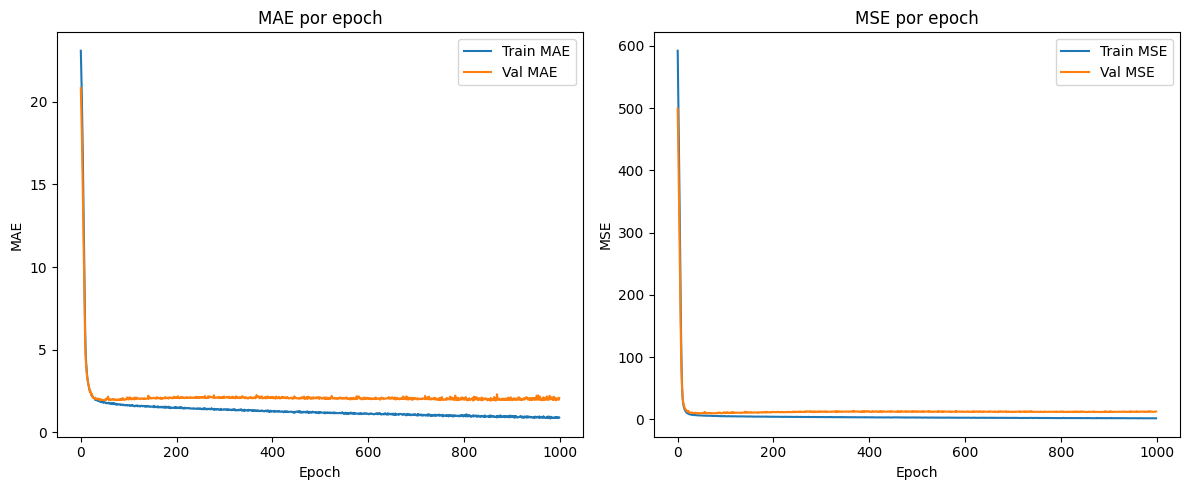

In [15]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist['epoch'], hist['mae'], label='Train MAE')
plt.plot(hist['epoch'], hist['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.title('MAE por epoch')

plt.subplot(1, 2, 2)
plt.plot(hist['epoch'], hist['mse'], label='Train MSE')
plt.plot(hist['epoch'], hist['val_mse'], label='Val MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.title('MSE por epoch')

plt.tight_layout()
plt.show()

¿Alguna conclusión respecto a este gráfico?

El error baja rápido al principio y luego empieza a subir mientras el de train sigue bajando, hay poquito overfitting.

Veamos qué tan bien generaliza el modelo al usar el conjunto de **test**. Esto nos dice qué tan bien podemos esperar que el modelo prediga cuándo lo usamos en el mundo real. Utiliza el método `evaluate` con los datos de test normalizados y sus labels.

Con el método evaluate devolverá tres valores: loss, mae y mse.

Ahora prueba el modelo. Coge 10 ejemplos de test y llama a` model.predict`.

In [16]:
loss, mae, mse = model.evaluate(X_test_std, y_test, verbose=2)
print(f"\nTest MAE: {mae:.2f} MPG")

y_pred = model.predict(X_test_std[:10])
print("Predicciones:", y_pred.flatten())
print("Reales:      ", y_test[:10].values)

3/3 - 0s - loss: 7.9629 - mae: 2.1788 - mse: 7.9629 - 201ms/epoch - 67ms/step

Test MAE: 2.18 MPG
1/1 [==============================] - 0s 98ms/step
Predicciones: [15.760174 15.813171 22.77919  23.64516  18.187202 13.993438 19.946356
 29.398113 26.356482 26.906342]
Reales:       [15. 14. 25. 24. 16. 13. 18. 23. 28. 30.]


### Haz Predicciones

Dibuja en un scatter plot las predicciones de test vs sus true labels.

3/3 [==============================] - 0s 2ms/step


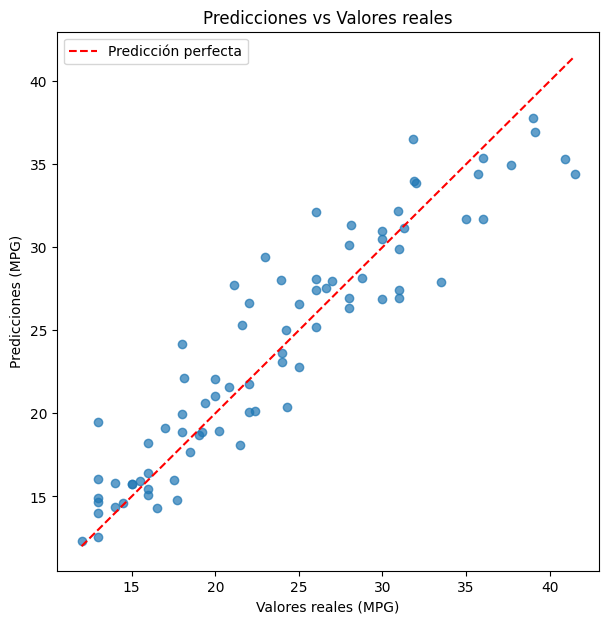

In [17]:
y_pred_all = model.predict(X_test_std).flatten()

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_all, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Predicción perfecta')
plt.xlabel('Valores reales (MPG)')
plt.ylabel('Predicciones (MPG)')
plt.title('Predicciones vs Valores reales')
plt.legend();

Parece que nuestro modelo predice razonablemente bien. Echemos un vistazo a la distribución de errores.

Representa los residuos en un histograma

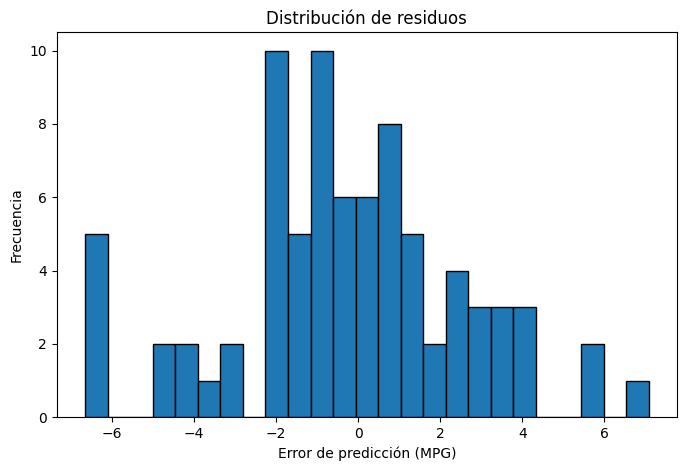

In [18]:
errores = y_test - y_pred_all

plt.figure(figsize=(8, 5))
plt.hist(errores, bins=25, edgecolor='black')
plt.xlabel('Error de predicción (MPG)')
plt.ylabel('Frecuencia')
plt.title('Distribución de residuos');

No es del todo gaussiano, pero podríamos esperar eso porque el número de muestras es muy pequeño.

Guarda tu modelo en un archivo.

In [19]:
model.save('modelo_mpg.keras')

## Conclusion

El modelo de regresión consigue predecir el consumo (MPG) con un error razonable. El scatter plot muestra que las predicciones se acercan bastante a la diagonal real. Los residuos se distribuyen aproximadamente alrededor de 0, lo que indica que no hay un sesgo sistemático, si tuviéramos más datos la distribución tendería a formar una gaussiana.